# Stage 2: Teeth Detection & Enumeration

This notebook runs Stage 2 of the pipeline: detecting and enumerating individual teeth inside each quadrant crop produced in Stage 1. We load the trained YOLO model, compare its best and last checkpoints on the test split, then sanity-check its predictions the same way we did in Stage 1.

`smart_predict` and `compare_best_vs_last` are utility functions from `src/model_utils.py`, not defined in this notebook.

In [2]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')
# add the project root to the path so the src package can be imported
sys.path.append(os.path.abspath('..'))

import yaml
from ultralytics import YOLO
from src.model_utils import smart_predict,compare_best_vs_last

%matplotlib inline

## Load configs

We'll load the stage 2 config, the YOLO data yaml for the enumeration task, and the trained models config that `compare_best_vs_last` needs to know which checkpoints to compare. The next few cells just print each one out for a quick look.

In [3]:
with open('../configs/stage2.yaml','r') as f:

    stage2_config = yaml.safe_load(f)


# this path comes from inside stage2_config, so stage2 has to load first
with open(stage2_config['model_args']['data'],'r') as f:

    enum_data_yaml = yaml.safe_load(f)


# separate config listing which checkpoints (best/last) exist for comparison
with open('../configs/trained_models.yaml','r') as f:

    trained_models_config = yaml.safe_load(f)

In [ ]:
stage2_config

{'paths': {'original_images_path': '../Data/Raw/DENTEX CHALLENGE 2023/Training_data/quadrant-enumeration/xrays',
  'original_json_path': '../Data/Raw/DENTEX CHALLENGE 2023/Training_data/quadrant-enumeration/train_quadrant_enumeration.json',
  's2_main_path': '../Data/Processed/Stage 2 (Enumeration Detection)',
  'runs_s2_output': '../Runs/Stage 2'},
 'model_args': {'data': '../Data/Processed/Stage 2 (Enumeration Detection)/data.yaml',
  'model': '../Models/yolo26s.pt',
  'epochs': 70,
  'save': True,
  'imgsz': 1280,
  'batch': 16,
  'patience': 20,
  'optimizer': 'AdamW',
  'lr0': 0.001,
  'lrf': 0.01,
  'plots': True,
  'verbose': True,
  'device': 'cuda',
  'workers': 4,
  'project': 'Runs',
  'name': 'Stage 2',
  'save_dir': '../Runs/Stage 2',
  'auto_augment': 'None',
  'augment': True,
  'mosaic': 0.0,
  'mixup': 0.0,
  'copy_paste': 0.0,
  'cutmix': 0.0,
  'hsv_h': 0.015,
  'hsv_s': 0.4,
  'hsv_v': 0.4,
  'degrees': 5.0,
  'translate': 0.05,
  'scale': 0.1,
  'shear': 0.0,
  'pe

In [ ]:
enum_data_yaml

{'train': '../Data/Processed/Stage 2 (Enumeration Detection)/train/images',
 'val': '../Data/Processed/Stage 2 (Enumeration Detection)/valid/images',
 'test': '../Data/Processed/Stage 2 (Enumeration Detection)/test/images',
 'nc': 8,
 'names': [0, 1, 2, 3, 4, 5, 6, 7]}

In [ ]:
trained_models_config

{'quadrant_detection_model': {'best': '../Runs/Stage 1/weights/best.pt',
  'last': '../Runs/Stage 1/weights/last.pt'},
 'enumeration_detection_model': {'best': '../Runs/Stage 2/weights/best.pt',
  'last': '../Runs/Stage 2/weights/last.pt'},
 'disease_classification_model': {'best': '../Runs/Stage 3/weights/best.pt',
  'last': '../Runs/Stage 3/weights/last.pt'}}

## Load the teeth detection model

Same pattern as Stage 1: start from the base checkpoint, then train, commented out here since it's already done. Before picking a checkpoint for inference, we compare the best and last one on the test split, then load whichever one we're using going forward.

In [ ]:
# load the base checkpoint specified in the config, this is the starting point before training
yolo_model = YOLO(stage2_config['model_args']['model'])

In [ ]:
# training already ran once; left here commented out for reference
# yolo_model.train(**stage2_config['model_args'])

In [ ]:
# compare the best vs last checkpoint on the enumeration task using the test split
results = compare_best_vs_last(enum_data_yaml,trained_models_config,
                                stage='enumeration', split_name = 'test',
                                original_images_path=stage2_config['paths']['original_images_path'],
                                annotations_df_path=os.path.join(stage2_config['paths']['s2_main_path'], 'test_df (splitted).pkl'),
                                results_csv_path= os.path.join(stage2_config['paths']['runs_s2_output'], 'results.csv'))


In [ ]:
# load the checkpoint saved at the best of teeth training, this is the model we'll actually use for inference
teeth_model_detection = YOLO(trained_models_config['enumeration_detection_model']['best'])

## Sanity-check predictions

Same checks as Stage 1, now on teeth detection. We'll call `smart_predict` a few times: plain, saving the annotated output, saving cropped teeth, and comparing predictions against the ground-truth boxes.


image 1/1 c:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\Projects\GitHub - Kaggle Projects\dental-xray-ai\Notebooks\..\Data\Processed\Stage 2 (Enumeration Detection)\test\images\train_386_UpperRight.png: 736x1280 1 0, 1 1, 2 4s, 1 5, 26.4ms
Speed: 6.2ms preprocess, 26.4ms inference, 0.5ms postprocess per image at shape (1, 3, 736, 1280)
Class Name: 5
Coordinates: [171.29808044433594, 11.348593711853027, 328.8341979980469, 316.552978515625]
Confidence: %88.0
Class Name: 4
Coordinates: [298.8088073730469, 49.88486099243164, 443.798828125, 358.15362548828125]
Confidence: %85.0
Class Name: 4
Coordinates: [413.8458251953125, 43.69062042236328, 533.0020141601562, 371.3406982421875]
Confidence: %84.0
Class Name: 0
Coordinates: [613.5131225585938, 57.01110076904297, 710.263671875, 392.915283203125]
Confidence: %80.0
Class Name: 1
Coordinates: [544.0719604492188, 52.51206970214844, 631.885009765625, 380.45513916015625]
Confidence: %73.0


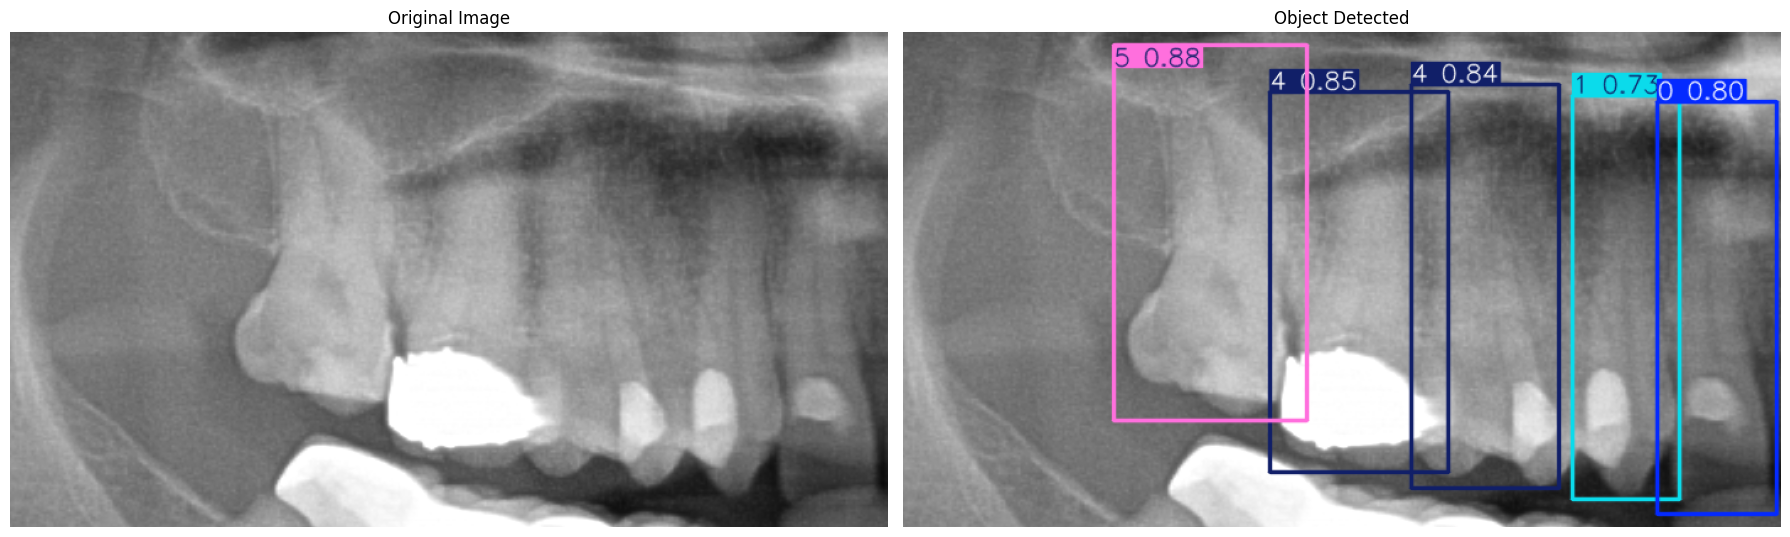

In [ ]:
# run with default settings first, just to confirm the model loads and predicts fine
smart_predict(teeth_model_detection,enum_data_yaml['test'])


image 1/1 c:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\Projects\GitHub - Kaggle Projects\dental-xray-ai\Notebooks\..\Data\Processed\Stage 2 (Enumeration Detection)\test\images\train_355_UpperRight.png: 640x1280 1 0, 1 1, 1 2, 1 3, 1 4, 1 5, 1 6, 84.3ms
Speed: 7.3ms preprocess, 84.3ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 1280)
Class Name: 5
Coordinates: [227.0880889892578, 38.32844924926758, 399.9495849609375, 356.2017822265625]
Confidence: %96.0
Class Name: 0
Coordinates: [668.0394287109375, 16.057064056396484, 784.5236206054688, 376.5887451171875]
Confidence: %96.0
Class Name: 6
Coordinates: [103.05885314941406, 30.63359260559082, 282.6666259765625, 341.82366943359375]
Confidence: %95.0
Class Name: 1
Coordinates: [602.392822265625, 26.917821884155273, 691.1438598632812, 370.6786193847656]
Confidence: %94.0
Class Name: 4
Coordinates: [357.3851623535156, 36.12504959106445, 477.8262023925781, 364.9358825683594]
Confidence: %94.0
Class Name: 2
Coordinates: [508.587

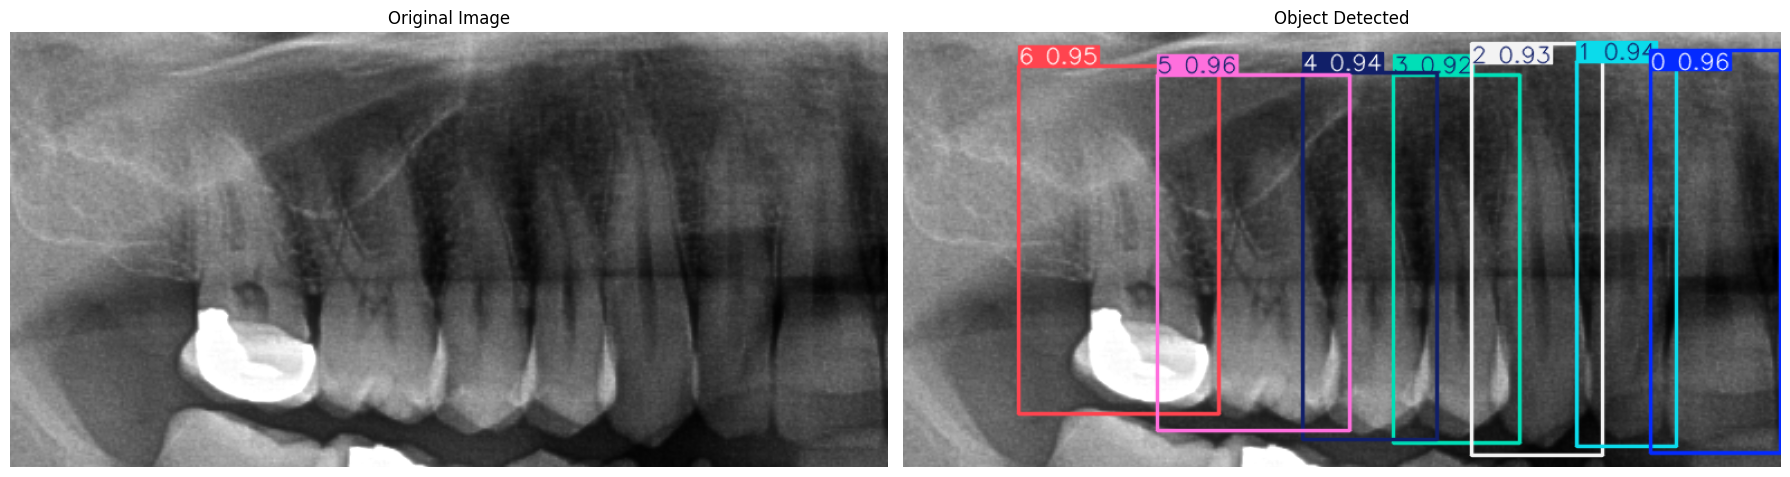

In [ ]:
# same predictions, but save the annotated output images this time
smart_predict(teeth_model_detection,enum_data_yaml['test'],save_output=True,save_dir=os.path.join(stage2_config['paths']['runs_s2_output'],'Test Outputs Predictions'))


image 1/1 c:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\Projects\GitHub - Kaggle Projects\dental-xray-ai\Notebooks\..\Data\Processed\Stage 2 (Enumeration Detection)\test\images\train_342_UpperRight.png: 896x1280 1 0, 1 1, 1 2, 1 3, 1 4, 1 5, 1 6, 1 7, 24.3ms
Speed: 10.2ms preprocess, 24.3ms inference, 0.6ms postprocess per image at shape (1, 3, 896, 1280)
Class Name: 0
Coordinates: [667.5253295898438, 157.8726043701172, 779.5012817382812, 520.2183227539062]
Confidence: %96.0
Class Name: 5
Coordinates: [235.0281982421875, 114.44280242919922, 405.0419921875, 452.2717590332031]
Confidence: %95.0
Class Name: 1
Coordinates: [590.8065795898438, 154.4676513671875, 687.7700805664062, 505.5126647949219]
Confidence: %95.0
Class Name: 6
Coordinates: [121.63396453857422, 102.51116180419922, 310.13702392578125, 418.515869140625]
Confidence: %95.0
Class Name: 2
Coordinates: [497.60882568359375, 126.0487289428711, 606.7872924804688, 496.7089538574219]
Confidence: %94.0
Class Name: 3
Coordinates: [424

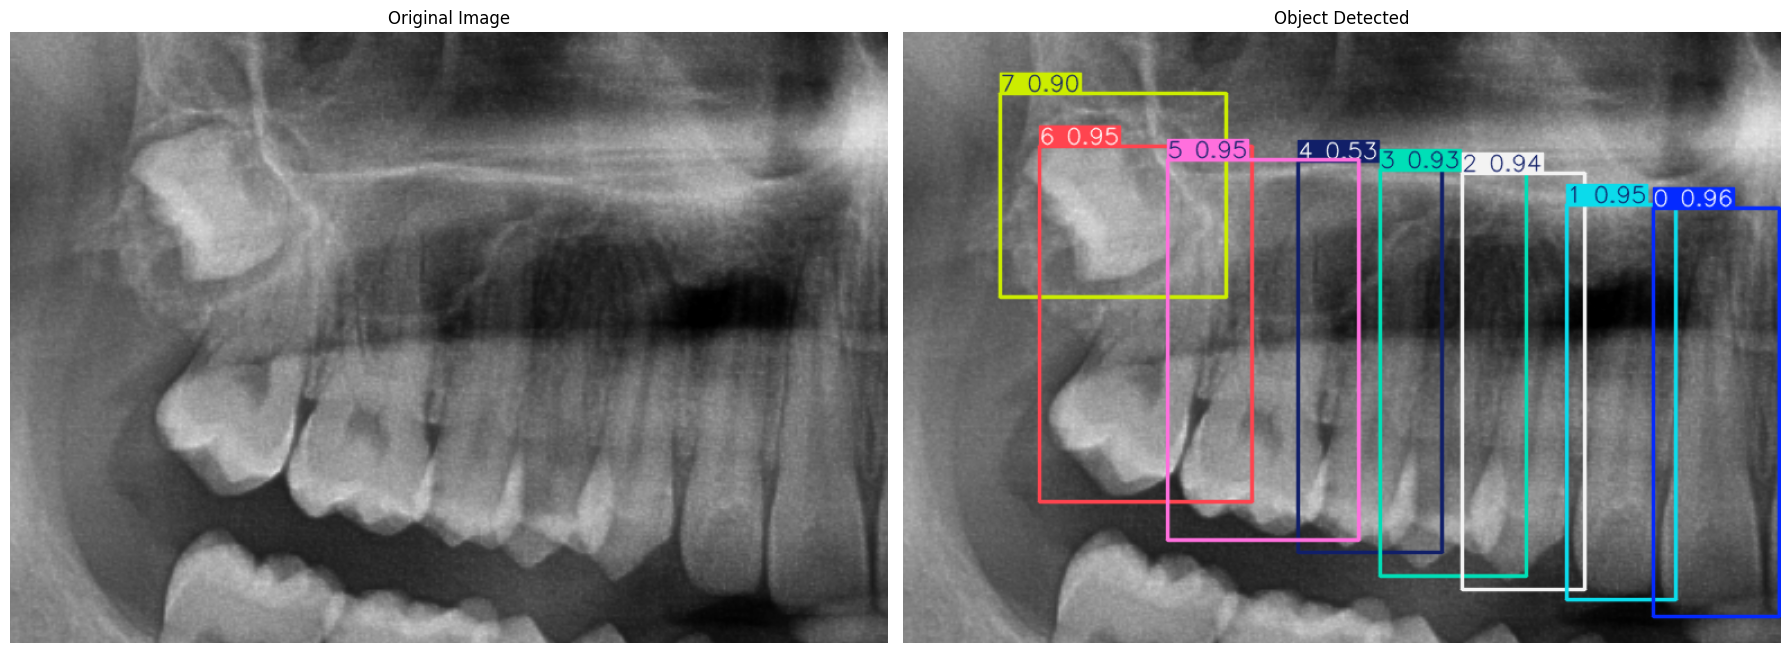

In [ ]:
# save the cropped teeth images instead of full annotated frames
smart_predict(teeth_model_detection,enum_data_yaml['test'],save_crop_output_image=True,save_dir=os.path.join(stage2_config['paths']['runs_s2_output'],'Test Outputs Predictions'))


image 1/1 c:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\Projects\GitHub - Kaggle Projects\dental-xray-ai\Notebooks\..\Data\Processed\Stage 2 (Enumeration Detection)\test\images\train_145_UpperLeft.png: 640x1280 1 0, 1 1, 1 2, 1 3, 1 4, 1 5, 1 6, 1 7, 322.5ms
Speed: 18.8ms preprocess, 322.5ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 1280)
Class Name: 0
Coordinates: [0.29012784361839294, 75.349853515625, 96.79439544677734, 367.74737548828125]
Confidence: %97.0
Class Name: 4
Coordinates: [272.8607482910156, 52.273963928222656, 392.92205810546875, 357.89202880859375]
Confidence: %96.0
Class Name: 2
Coordinates: [141.19032287597656, 41.143131256103516, 244.7932891845703, 364.3366394042969]
Confidence: %96.0
Class Name: 6
Coordinates: [479.7934265136719, 48.72349548339844, 627.68310546875, 353.13885498046875]
Confidence: %96.0
Class Name: 1
Coordinates: [79.7866439819336, 69.32169342041016, 156.1195068359375, 348.4198913574219]
Confidence: %96.0
Class Name: 7
Coordinates: 

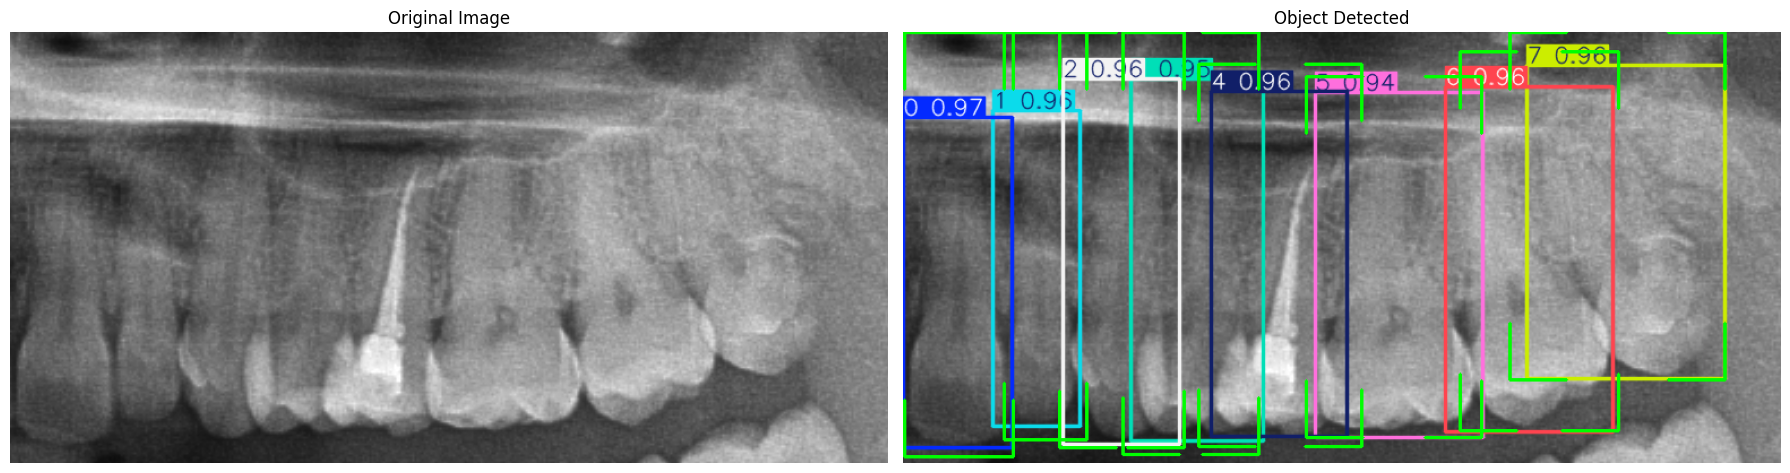

In [ ]:
# overlay the ground-truth boxes next to the predictions for a visual comparison
smart_predict(teeth_model_detection,enum_data_yaml['test'],show_true_boxes=True)


image 1/1 c:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\Projects\GitHub - Kaggle Projects\dental-xray-ai\Notebooks\..\Data\Processed\Stage 2 (Enumeration Detection)\test\images\train_355_LowerRight.png: 768x1280 1 0, 1 1, 1 2, 1 3, 1 4, 1 5, 1 6, 117.8ms
Speed: 12.4ms preprocess, 117.8ms inference, 0.5ms postprocess per image at shape (1, 3, 768, 1280)
Class Name: 0
Coordinates: [785.6795043945312, 118.48395538330078, 876.07373046875, 434.0381774902344]
Confidence: %95.0
Class Name: 5
Coordinates: [227.17335510253906, 87.0454330444336, 505.7327575683594, 408.13287353515625]
Confidence: %94.0
Class Name: 1
Coordinates: [712.2362060546875, 117.52665710449219, 821.896240234375, 445.0766906738281]
Confidence: %93.0
Class Name: 4
Coordinates: [493.905029296875, 101.48722839355469, 615.7950439453125, 448.71966552734375]
Confidence: %93.0
Class Name: 3
Coordinates: [575.8704833984375, 110.14189910888672, 669.37158203125, 464.3889465332031]
Confidence: %92.0
Class Name: 2
Coordinates: [647.454

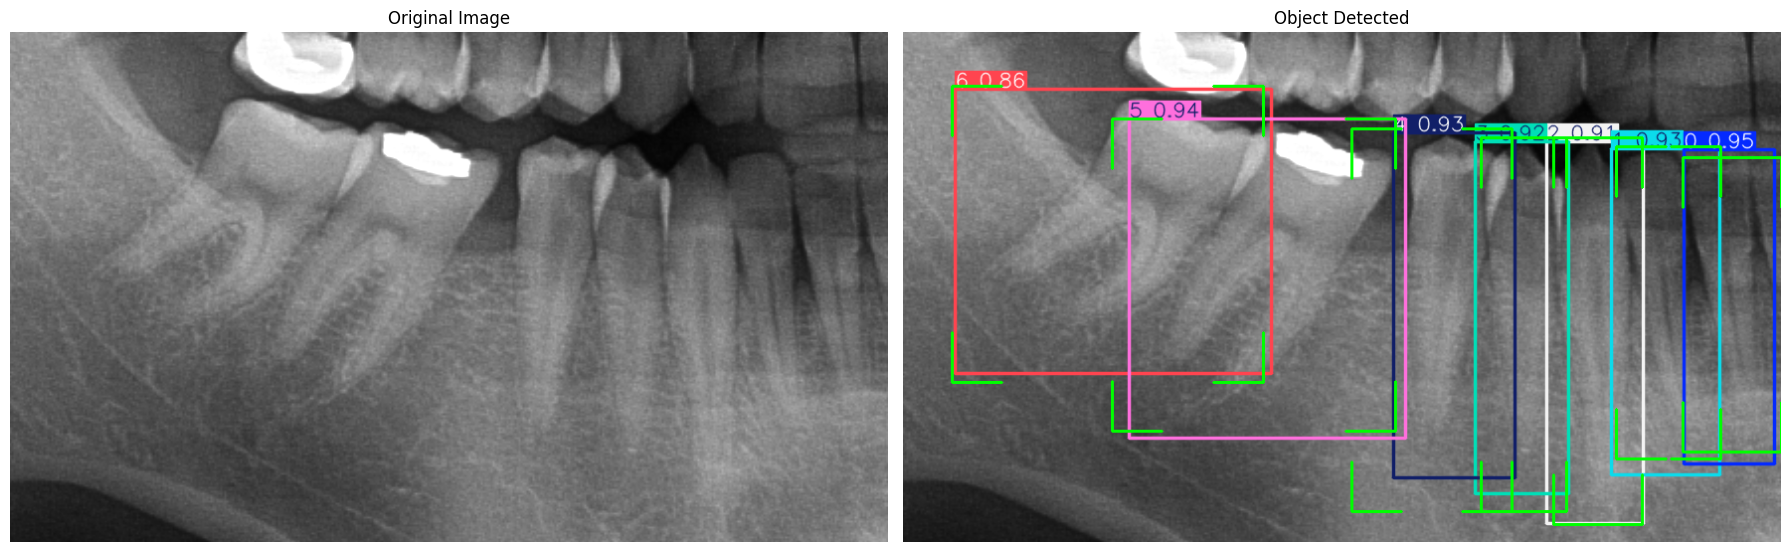

In [ ]:
# same check as above, run again for a second look
smart_predict(teeth_model_detection,enum_data_yaml['test'],show_true_boxes=True)